## Exercise 1.4 Hotdog -- no hotdog
This is the poster hand-in project for the course. Please see the associated PDF for instructions.

In [1]:
import os
import numpy as np
import glob
import PIL.Image as Image
from tqdm.notebook import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.datasets as datasets
from torch.utils.data import DataLoader
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

%matplotlib inline

We always check that we are running on a GPU

In [2]:
if torch.cuda.is_available():
    print("The code will run on GPU.")
else:
    print("The code will run on CPU. Go to Edit->Notebook Settings and choose GPU as the hardware accelerator")
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

The code will run on GPU.


We provide you with a class that can load the *hotdog/not hotdog* dataset you should use from /dtu/datasets1/02516/

In [3]:
class Hotdog_NotHotdog(torch.utils.data.Dataset):
    def __init__(self, train, transform, data_path='./data/hotdog_nothotdog'):
        'Initialization'
        self.transform = transform
        data_path = os.path.join(data_path, 'train' if train else 'test')
        image_classes = [os.path.split(d)[1] for d in glob.glob(data_path +'/*') if os.path.isdir(d)]
        print(f"Found {len(image_classes)} classes")
        image_classes.sort()
        self.name_to_label = {c: id for id, c in enumerate(image_classes)}
        self.image_paths = glob.glob(data_path + '/*/*.jpg')
        
    def __len__(self):
        'Returns the total number of samples'
        return len(self.image_paths)

    def __getitem__(self, idx):
        'Generates one sample of data'
        image_path = self.image_paths[idx]
        
        image = Image.open(image_path)
        c = os.path.split(os.path.split(image_path)[0])[1]
        y = self.name_to_label[c]
        X = self.transform(image)
        return X, y

Below is the simple way of converting the images to something that can be fed through a network.
Feel free to use something other than $128\times128$ images.

In [4]:
size = 128
train_transform = transforms.Compose([transforms.Resize((size, size)), 
                                    transforms.ToTensor()])
test_transform = transforms.Compose([transforms.Resize((size, size)), 
                                    transforms.ToTensor()])

batch_size = 256 # I got dat big gpu!
trainset = Hotdog_NotHotdog(train=True, transform=train_transform)
train_loader = DataLoader(trainset, batch_size=batch_size, shuffle=True, num_workers=3)
testset = Hotdog_NotHotdog(train=False, transform=test_transform)
test_loader = DataLoader(testset, batch_size=batch_size, shuffle=False, num_workers=3)

print(f"Found {len(trainset)} train images")
print(f"Found {len(testset)} test images")

Found 2 classes
Found 2 classes
Found 2047 train images
Found 1862 test images


Let's look at some images from our data 

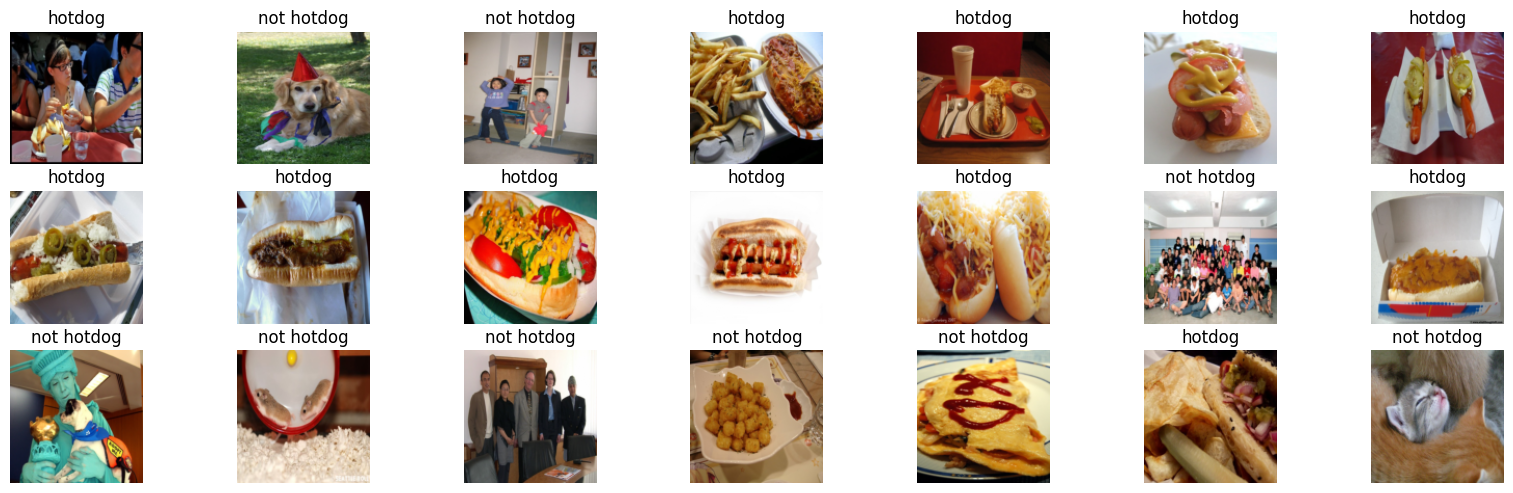

(3, 128, 128)


In [5]:
images, labels = next(iter(train_loader))
plt.figure(figsize=(20,10))

for i in range(21):
    plt.subplot(5,7,i+1)
    plt.imshow(np.swapaxes(np.swapaxes(images[i].numpy(), 0, 2), 0, 1))
    plt.title(['hotdog', 'not hotdog'][labels[i].item()])
    plt.axis('off')

plt.show()
print(images[0].numpy().shape)

Now create a model and train it!


In [6]:
class VGG16(nn.Module):
    def __init__(self, num_classes=10):
        super(VGG16, self).__init__()
        self.layer1 = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU())
        self.layer2 = nn.Sequential(
            nn.Conv2d(64, 64, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(), 
            nn.MaxPool2d(kernel_size = 2, stride = 2)) # 128x128 -> 64x64
        self.layer3 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU())
        self.layer4 = nn.Sequential(
            nn.Conv2d(128, 128, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size = 2, stride = 2)) # 64->32
        self.layer5 = nn.Sequential(
            nn.Conv2d(128, 256, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU())
        self.layer6 = nn.Sequential(
            nn.Conv2d(256, 256, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU())
        self.layer7 = nn.Sequential(
            nn.Conv2d(256, 256, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size = 2, stride = 2)) # 16
        self.layer8 = nn.Sequential(
            nn.Conv2d(256, 512, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU())
        self.layer9 = nn.Sequential(
            nn.Conv2d(512, 512, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU())
        self.layer10 = nn.Sequential(
            nn.Conv2d(512, 512, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size = 2, stride = 2)) # 8
        self.layer11 = nn.Sequential(
            nn.Conv2d(512, 512, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU())
        self.layer12 = nn.Sequential(
            nn.Conv2d(512, 512, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU())
        self.layer13 = nn.Sequential(
            nn.Conv2d(512, 512, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size = 2, stride = 2)) # 4
        self.fc = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(4*4*512, 4096),
            nn.ReLU())
        self.fc1 = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(4096, 4096),
            nn.ReLU())
        self.fc2= nn.Sequential(
            nn.Linear(4096, num_classes))
        
    def forward(self, x):
        out = self.layer1(x)
        out = self.layer2(out)
        out = self.layer3(out)
        out = self.layer4(out)
        out = self.layer5(out)
        out = self.layer6(out)
        out = self.layer7(out)
        out = self.layer8(out)
        out = self.layer9(out)
        out = self.layer10(out)
        out = self.layer11(out)
        out = self.layer12(out)
        out = self.layer13(out)
        out = out.reshape(out.size(0), -1)
        out = self.fc(out)
        out = self.fc1(out)
        out = self.fc2(out)
        return out
    

In [7]:
num_classes = 2
num_epochs = 20
batch_size = 64
learning_rate = 0.005

model = VGG16(num_classes).to(device)

# Loss and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(
    model.parameters(), lr=learning_rate, weight_decay=0.005, momentum=0.9
)

history = []

# Train the model
for epoch in range(num_epochs):
    model.train()
    
    # Wrap train_loader with tqdm and track running loss
    train_bar = tqdm(
        train_loader, 
        desc=f"Epoch [{epoch + 1}/{num_epochs}] Train", 
        leave=False
    )
    
    for images, labels in train_bar:
        images = images.to(device)
        labels = labels.to(device)

        # Forward pass
        outputs = model(images)
        loss = criterion(outputs, labels)

        # Backward and optimize
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_bar.set_postfix(loss=f"{loss.item():.4f}")

    # Validation
    model.eval()
    correct = 0
    total = 0
    
    val_bar = tqdm(
        test_loader, 
        desc=f"Epoch [{epoch + 1}/{num_epochs}] Val", 
        leave=False
    )
    
    with torch.no_grad():
        for images, labels in val_bar:
            images = images.to(device)
            labels = labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    val_accuracy = 100 * correct / total
    print(
        f"Epoch [{epoch + 1}/{num_epochs}] | "
        f"Train Loss: {loss.item():.4f} | "
        f"Val Accuracy: {val_accuracy:.2f}%"
    )
    
    history.append({
        "epoch": epoch + 1,
        "acc": val_accuracy,
        "loss": loss
    })

Epoch [1/20] Train:   0%|          | 0/8 [00:00<?, ?it/s]

Epoch [1/20] Val:   0%|          | 0/8 [00:00<?, ?it/s]

Epoch [1/20] | Train Loss: 0.6909 | Val Accuracy: 48.07%


Epoch [2/20] Train:   0%|          | 0/8 [00:00<?, ?it/s]

Epoch [2/20] Val:   0%|          | 0/8 [00:00<?, ?it/s]

...

Epoch [19/20] Val:   0%|          | 0/8 [00:00<?, ?it/s]

Epoch [19/20] | Train Loss: 0.0294 | Val Accuracy: 75.67%


Epoch [20/20] Train:   0%|          | 0/8 [00:00<?, ?it/s]

Epoch [20/20] Val:   0%|          | 0/8 [00:00<?, ?it/s]

Epoch [20/20] | Train Loss: 0.0307 | Val Accuracy: 76.85%


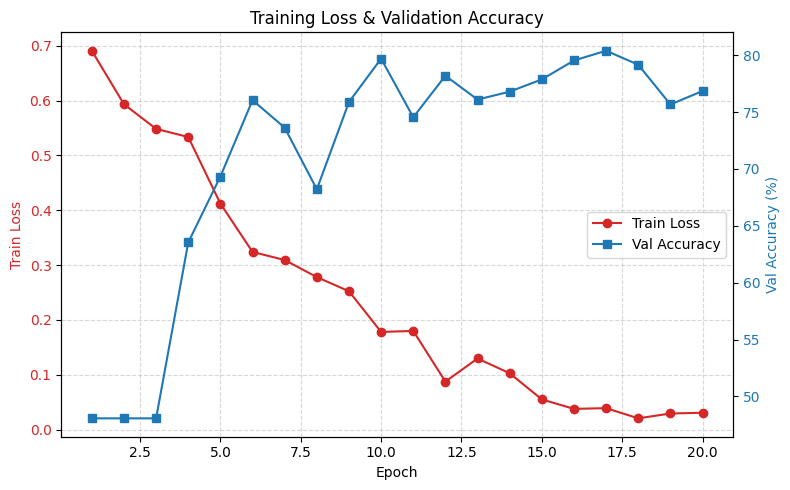

In [9]:
# Extract metrics
epochs = [entry["epoch"] for entry in history]
accs = [entry["acc"] for entry in history]
losses = [
    entry["loss"].item()
    if hasattr(entry["loss"], "item")
    else entry["loss"]
    for entry in history
]

# Single plot with dual y-axes
fig, ax1 = plt.subplots(figsize=(8, 5))

# Loss on primary y-axis (left)
color = "tab:red"
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Train Loss", color=color)
line1 = ax1.plot(epochs, losses, color=color, marker="o", label="Train Loss")
ax1.tick_params(axis="y", labelcolor=color)
ax1.grid(True, linestyle="--", alpha=0.5)

# Accuracy on secondary y-axis (right)
ax2 = ax1.twinx()
color = "tab:blue"
ax2.set_ylabel("Val Accuracy (%)", color=color)
line2 = ax2.plot(epochs, accs, color=color, marker="s", label="Val Accuracy")
ax2.tick_params(axis="y", labelcolor=color)

# Combined legend
lines = line1 + line2
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc="center right")

plt.title("Training Loss & Validation Accuracy")
plt.tight_layout()
plt.show()

Credit to: https://www.digitalocean.com/community/tutorials/vgg-from-scratch-pytorch \
And original paper: https://arxiv.org/abs/1409.1556